In [1]:
import pandas as pd


In [2]:

# تحميل البيانات
df = pd.read_csv("telecom_churn.csv")

# عرض أول 5 أسطر
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# عدد الصفوف والأعمدة
df.shape


(7043, 21)

In [4]:
# معلومات عامة عن البيانات
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# إحصائيات للمتغيرات الرقمية
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# توزيع المتغير الهدف
df["Churn"].value_counts()


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
df["Churn"].value_counts(normalize=True)


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [8]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

categorical_cols, numerical_cols


(Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
        'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
        'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
        'Churn'],
       dtype='object'),
 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object'))

preprocessing:

فحص القيم المفقودة:

In [9]:
# فحص القيم المفقودة في كل عمود
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
# التأكد من نوع العمود
df["TotalCharges"].dtype


dtype('O')

تحويل العمود إلى رقمي:

In [11]:
# تحويل TotalCharges إلى رقمي
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# عدد القيم المفقودة بعد التحويل
df["TotalCharges"].isnull().sum()


11

معالجة القيم المفقودة الناتجة


القيم المفقودة ظهرت لأن العملاء الجدد لم يدفعوا أي مبلغ بعد

حذفهم قد يؤدي إلى فقدان معلومات مهمة

قمنا بتعويض القيم المفقودة بالقيمة 0

In [12]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)


In [13]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

فحص القيم المفقودة وحده غير كافٍ
ويجب فحص نوع البيانات ومحتواها

قمنا بتحويل totalcharges على الرغم من عدم وجود قيم فارغة في البداية الا ان لأن القيم الفارغة النصية لا تُكتشف كـ NaN، لكنها تمنع أي عملية تحليل أو نمذجة رقمية.

فصل الأعمدة:

In [14]:
# حذف العمود غير التحليلي
df = df.drop(columns=["customerID"])

# الأعمدة الثنائية (Yes / No)
binary_cols = [
    "gender", "Partner", "Dependents", "PhoneService",
    "PaperlessBilling", "Churn"
]

# الأعمدة متعددة القيم
multi_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"
]

binary_cols, multi_cols


(['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'PaperlessBilling',
  'Churn'],
 ['MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaymentMethod'])

Label Encoding (للأعمدة الثنائية)

Churn:

1 = Yes (غادر)

0 = No (مستمر)

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df[binary_cols].head()


,gender,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,0,1,0,0,1,0
1,1,0,0,1,0,0
2,1,0,0,1,1,1
3,1,0,0,0,0,0
4,0,0,0,1,1,1


One-Hot Encoding (للأعمدة متعددة القيم)

In [16]:
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [17]:
df.shape


(7043, 31)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int32  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int32  
 3   Dependents                             7043 non-null   int32  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int32  
 6   PaperlessBilling                       7043 non-null   int32  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int32  
 10  MultipleLines_No phone service         7043 non-null   bool   
 11  Mult

نلاحظ انه لا يوجد اي

dtype=object

ايضا churn اصبح رقمي

و زاد عدد الاعمدة

فصل الميزات عن المتغير الهدف:

In [19]:

X = df.drop(columns=["Churn"])
y = df["Churn"]

X.shape, y.shape


((7043, 30), (7043,))

تقسيم البيانات (Train / Test Split)

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((5634, 30), (1409, 30))

In [21]:
y_train.value_counts()


Churn
0    4139
1    1495
Name: count, dtype: int64

In [22]:
y_train.value_counts(normalize=True)


Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

In [23]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [24]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

X_train_smote.shape, y_train_smote.shape


((8278, 30), (8278,))

In [25]:
y_train_smote.value_counts()


Churn
0    4139
1    4139
Name: count, dtype: int64

In [26]:
y_train_smote.value_counts(normalize=True)


Churn
0    0.5
1    0.5
Name: proportion, dtype: float64

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, roc_curve
)
import matplotlib.pyplot as plt


In [28]:
# إنشاء النموذج
log_reg = LogisticRegression(max_iter=2000, random_state=42, solver='liblinear', class_weight='balanced')

# التدريب على بيانات التدريب الأصلية
log_reg.fit(X_train_smote, y_train_smote)

# التنبؤ على بيانات الاختبار
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]


In [29]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Accuracy: 0.7466288147622427
Precision: 0.5185995623632386
Recall: 0.6336898395721925
F1-score: 0.5703971119133574
ROC-AUC: 0.8069312046294144


In [30]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.86      0.79      0.82      1035
           1       0.52      0.63      0.57       374

    accuracy                           0.75      1409
   macro avg       0.69      0.71      0.70      1409
weighted avg       0.77      0.75      0.75      1409



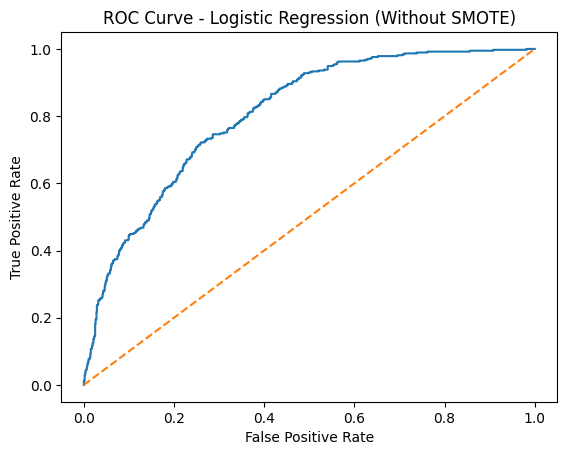

In [31]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (Without SMOTE)")
plt.show()


In [32]:
# نموذج جديد
log_reg_smote = LogisticRegression(max_iter=1000, random_state=42)

# التدريب على بيانات SMOTE
log_reg_smote.fit(X_train_smote, y_train_smote)

# التنبؤ
y_pred_smote = log_reg_smote.predict(X_test)
y_prob_smote = log_reg_smote.predict_proba(X_test)[:, 1]


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [33]:
print("Accuracy (SMOTE):", accuracy_score(y_test, y_pred_smote))
print("Precision (SMOTE):", precision_score(y_test, y_pred_smote))
print("Recall (SMOTE):", recall_score(y_test, y_pred_smote))
print("F1-score (SMOTE):", f1_score(y_test, y_pred_smote))
print("ROC-AUC (SMOTE):", roc_auc_score(y_test, y_prob_smote))


Accuracy (SMOTE): 0.7487579843860894
Precision (SMOTE): 0.5226244343891403
Recall (SMOTE): 0.6176470588235294
F1-score (SMOTE): 0.5661764705882353
ROC-AUC (SMOTE): 0.8043142421659045


In [34]:
print(classification_report(y_test, y_pred_smote))


              precision    recall  f1-score   support

           0       0.85      0.80      0.82      1035
           1       0.52      0.62      0.57       374

    accuracy                           0.75      1409
   macro avg       0.69      0.71      0.69      1409
weighted avg       0.76      0.75      0.75      1409



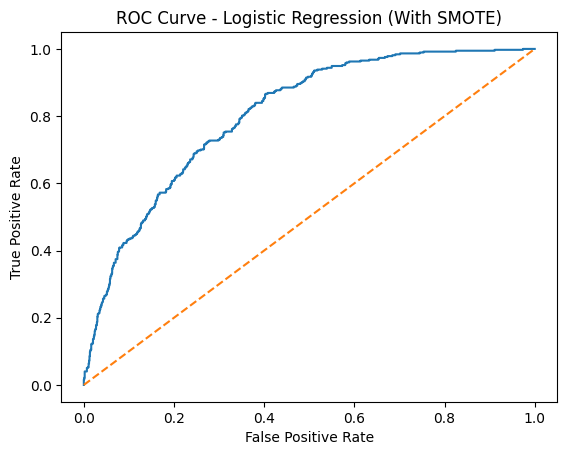

In [35]:
fpr_s, tpr_s, _ = roc_curve(y_test, y_prob_smote)

plt.figure()
plt.plot(fpr_s, tpr_s)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (With SMOTE)")
plt.show()


استخدام Random forest


تدريب النموذج وتقييمه بلا smote

In [36]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]


In [37]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


Accuracy: 0.7906316536550745
Precision: 0.6338983050847458
Recall: 0.5
F1-score: 0.5590433482810164
ROC-AUC: 0.8248740602960553


In [38]:
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



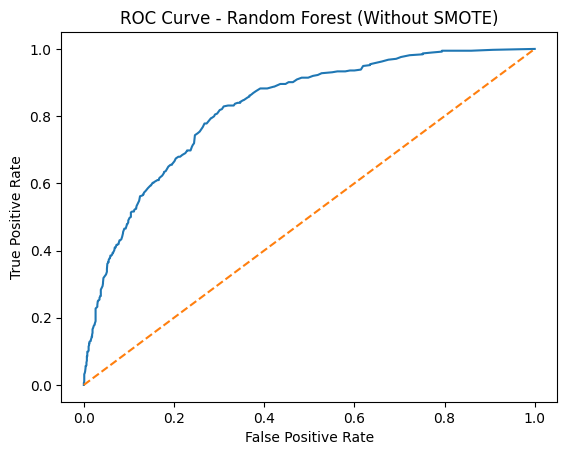

In [39]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure()
plt.plot(fpr_rf, tpr_rf)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest (Without SMOTE)")
plt.show()


التدريب و التقييم مع smote

In [40]:
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)

y_pred_rf_smote = rf_smote.predict(X_test)
y_prob_rf_smote = rf_smote.predict_proba(X_test)[:, 1]


In [41]:
print("Accuracy (SMOTE):", accuracy_score(y_test, y_pred_rf_smote))
print("Precision (SMOTE):", precision_score(y_test, y_pred_rf_smote))
print("Recall (SMOTE):", recall_score(y_test, y_pred_rf_smote))
print("F1-score (SMOTE):", f1_score(y_test, y_pred_rf_smote))
print("ROC-AUC (SMOTE):", roc_auc_score(y_test, y_prob_rf_smote))


Accuracy (SMOTE): 0.7707594038325053
Precision (SMOTE): 0.5645569620253165
Recall (SMOTE): 0.5962566844919787
F1-score (SMOTE): 0.5799739921976593
ROC-AUC (SMOTE): 0.8179841897233201


In [42]:
print(classification_report(y_test, y_pred_rf_smote))


              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1035
           1       0.56      0.60      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409



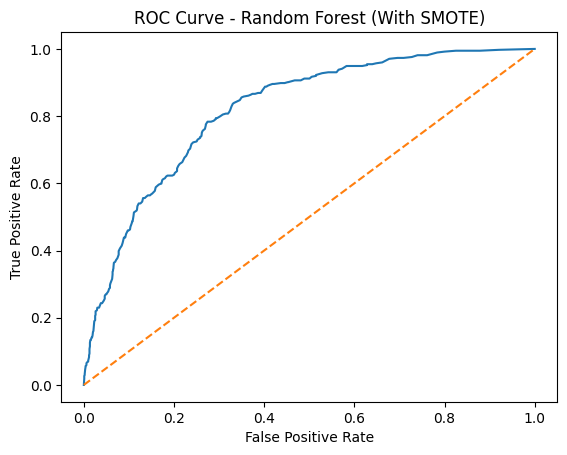

In [43]:
fpr_rf_s, tpr_rf_s, _ = roc_curve(y_test, y_prob_rf_smote)

plt.figure()
plt.plot(fpr_rf_s, tpr_rf_s)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest (With SMOTE)")
plt.show()


Unsupervised Learning – Clustering

In [44]:
# اختيار الميزات الرقمية للتجميع
cluster_features = df[["tenure", "MonthlyCharges", "TotalCharges"]]

cluster_features.head()


,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65


In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

X_scaled[:5]


array([[-1.27744458, -1.16032292, -0.99261052],
       [ 0.06632742, -0.25962894, -0.17216471],
       [-1.23672422, -0.36266036, -0.9580659 ],
       [ 0.51425142, -0.74653546, -0.19367238],
       [-1.23672422,  0.19736523, -0.93887444]])

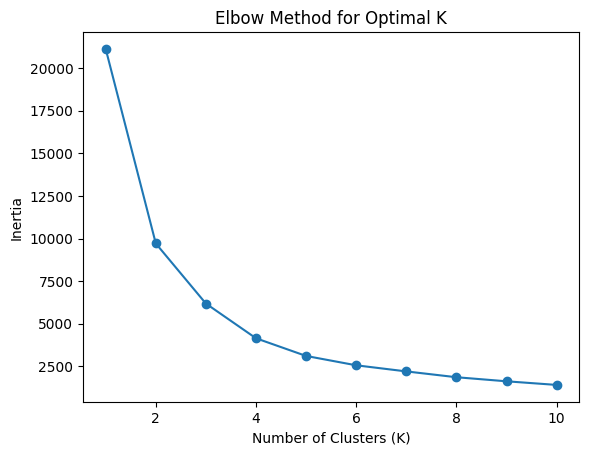

In [46]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(k_range, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()


In [47]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df[["Cluster"]].value_counts()


Cluster
2          2276
1          1904
0          1703
3          1160
Name: count, dtype: int64

In [48]:
cluster_summary = df.groupby("Cluster")[["tenure", "MonthlyCharges", "TotalCharges"]].mean()
cluster_summary


,tenure,MonthlyCharges,TotalCharges
Cluster,,,
0,10.214915,31.775661,302.152378
1,59.530987,93.306224,5548.653887
2,15.424868,80.779657,1251.165224
3,53.568966,34.907845,1835.615647


In [49]:
churn_rate = df.groupby("Cluster")["Churn"].mean()
churn_rate


Cluster
0    0.246624
1    0.153887
2    0.482425
3    0.050000
Name: Churn, dtype: float64

الطلبات الاضافية:(bonus)

In [50]:
%pip install shap


Note: you may need to restart the kernel to use updated packages.


In [51]:
import shap
X_shap = X_train_smote.sample(500, random_state=42)
explainer = shap.TreeExplainer(rf_smote)
shap_values = explainer.shap_values(X_shap)


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


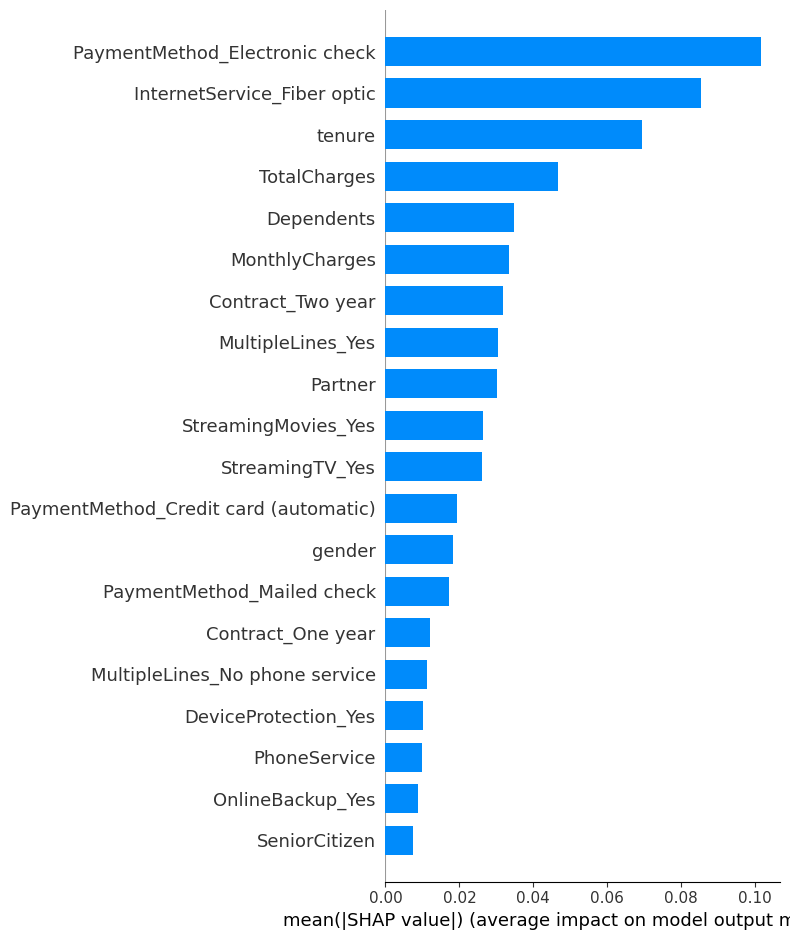

In [52]:
shap.summary_plot(
    shap_values[1],   # الفئة Churn = 1
    X_train_smote,
    plot_type="bar"
)


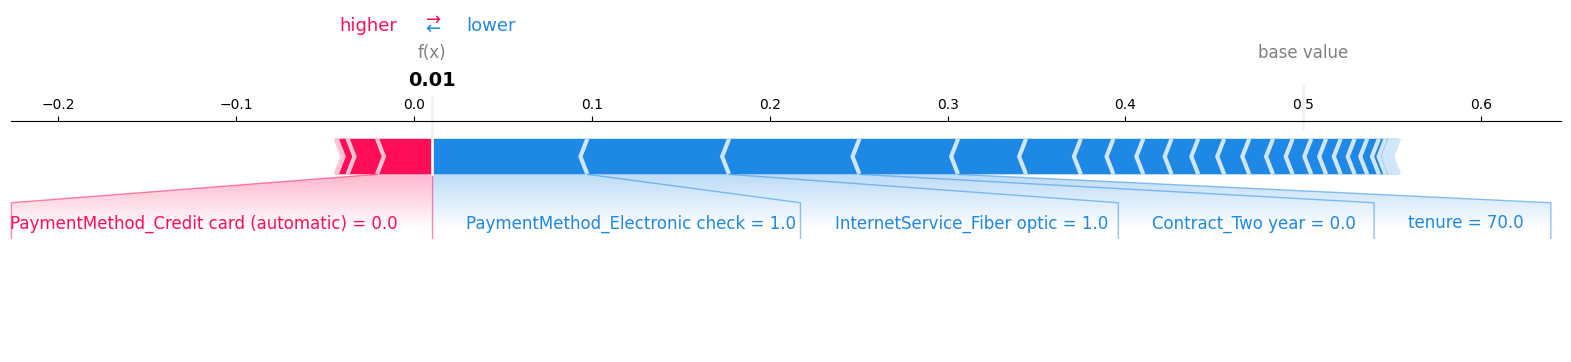

In [53]:
# اختيار عميل من بيانات الاختبار
i = 10

shap.force_plot(
    explainer.expected_value[1],
    shap_values[1][i],
    X_test.iloc[i],
    matplotlib=True
)


In [54]:
df["Churn_Probability"] = rf_smote.predict_proba(X)[:, 1]


In [55]:
df["Expected_Tenure"] = df["tenure"] / (1 - df["Churn_Probability"] + 1e-6)


In [56]:
df["CLTV"] = df["MonthlyCharges"] * df["Expected_Tenure"]


In [57]:
df["Risk_Level"] = pd.qcut(
    df["CLTV"],
    q=3,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

df["Risk_Level"].value_counts()


Risk_Level
Low Risk       2348
High Risk      2348
Medium Risk    2347
Name: count, dtype: int64

In [58]:
df.groupby("Risk_Level")["Churn"].mean()


The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


Risk_Level
Low Risk       0.169080
Medium Risk    0.181508
High Risk      0.445486
Name: Churn, dtype: float64

In [59]:
%pip install xgboost
from xgboost import XGBClassifier


Note: you may need to restart the kernel to use updated packages.


XGBoost بدون SMOTE

In [60]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1-score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))


Accuracy: 0.8005677785663591
Precision: 0.6524590163934426
Recall: 0.5320855614973262
F1-score: 0.5861561119293078
ROC-AUC: 0.8382430442532746


XGBoost مع SMOTE

In [61]:
xgb_smote = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42
)

xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_xgb_s = xgb_smote.predict(X_test)
y_prob_xgb_s = xgb_smote.predict_proba(X_test)[:, 1]

print("Accuracy (SMOTE):", accuracy_score(y_test, y_pred_xgb_s))
print("Precision (SMOTE):", precision_score(y_test, y_pred_xgb_s))
print("Recall (SMOTE):", recall_score(y_test, y_pred_xgb_s))
print("F1-score (SMOTE):", f1_score(y_test, y_pred_xgb_s))
print("ROC-AUC (SMOTE):", roc_auc_score(y_test, y_prob_xgb_s))


Accuracy (SMOTE): 0.7650816181689141
Precision (SMOTE): 0.550351288056206
Recall (SMOTE): 0.6283422459893048
F1-score (SMOTE): 0.5867665418227216
ROC-AUC (SMOTE): 0.8243121754630705


ROC Curve

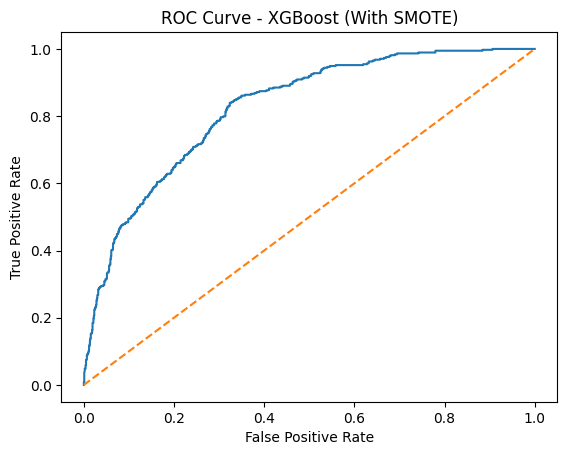

In [62]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb_s)

plt.figure()
plt.plot(fpr_xgb, tpr_xgb)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost (With SMOTE)")
plt.show()


In [63]:
%pip install streamlit


Note: you may need to restart the kernel to use updated packages.


In [64]:
import joblib

joblib.dump(xgb_smote, "churn_model_xgb.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "feature_names.pkl")


['feature_names.pkl']